In [1]:
# CELL 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import load_model
from scipy.stats import median_abs_deviation
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix)
import shap

print(f"✅ TensorFlow : {tf.__version__}")
print(f"✅ SHAP       : {shap.__version__}")
print(f"✅ GPU        : {tf.config.list_physical_devices('GPU')}")
print(f"✅ All libraries loaded!")

2026-04-18 15:36:06.131230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776526566.309554      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776526566.365008      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776526566.786408      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776526566.786446      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776526566.786449      55 computation_placer.cc:177] computation placer alr

✅ TensorFlow : 2.19.0
✅ SHAP       : 0.50.0
✅ GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ All libraries loaded!


In [2]:
# CELL 2 — Load all data and models (FIXED)
print("Loading all files...")
print("=" * 50)

# Search all input folders
day2_path       = None
cnn_path        = None
ae_path         = None
ae_results_path = None

for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        full = os.path.join(root, f)

        if f == 'X_train.npy' and day2_path is None:
            day2_path = root
            print(f"✅ Day 2 data      : {root}")

        if f == 'cnn_lstm_best.h5' and cnn_path is None:
            cnn_path = full
            print(f"✅ CNN-LSTM model  : {full}")

        if f == 'autoencoder_best.h5' and ae_path is None:
            ae_path = full
            print(f"✅ Autoencoder     : {full}")

        if f == 'autoencoder_results.json' \
                and ae_results_path is None:
            ae_results_path = full
            print(f"✅ AE results      : {full}")

# Check all found
print("\nStatus check:")
print(f"  Day 2 data  : {'✅' if day2_path else '❌ MISSING'}")
print(f"  CNN-LSTM    : {'✅' if cnn_path else '❌ MISSING'}")
print(f"  Autoencoder : {'✅' if ae_path else '❌ MISSING'}")
print(f"  AE results  : {'✅' if ae_results_path else '❌ MISSING'}")

# Load arrays
X_train = np.load(f'{day2_path}/X_train.npy')
X_test  = np.load(f'{day2_path}/X_test.npy')
y_train = np.load(f'{day2_path}/y_train.npy')
y_test  = np.load(f'{day2_path}/y_test.npy')

with open(f'{day2_path}/label_encoder.pkl','rb') as f:
    le = pickle.load(f)
with open(f'{day2_path}/top_features.pkl','rb') as f:
    top_features = pickle.load(f)

# Load CNN-LSTM model
cnn_model = load_model(cnn_path, compile=False)
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])
print("✅ CNN-LSTM loaded!")

# Load Autoencoder — FIXED for Keras mse issue
ae_model = load_model(
    ae_path,
    custom_objects={
        'mse': tf.keras.losses.MeanSquaredError()
    },
    compile=False
)
ae_model.compile(optimizer='adam', loss='mse')
print("✅ Autoencoder loaded!")

# Load AE threshold
with open(ae_results_path,'r') as f:
    ae_results = json.load(f)
threshold = ae_results['threshold']

n_classes  = len(le.classes_)
n_features = X_test.shape[1]
benign_idx = list(le.classes_).index('BENIGN')

print(f"\n✅ ALL FILES LOADED!")
print(f"   X_test shape : {X_test.shape}")
print(f"   Classes      : {n_classes}")
print(f"   Threshold    : {threshold:.6f}")
print(f"   Benign idx   : {benign_idx}")

Loading all files...
✅ AE results      : /kaggle/input/notebooks/mchandana086/day-5-autoencoder/autoencoder_results.json
✅ Autoencoder     : /kaggle/input/notebooks/mchandana086/day-5-autoencoder/autoencoder_best.h5
✅ Day 2 data      : /kaggle/input/notebooks/mchandana086/day-02-preprocessing
✅ CNN-LSTM model  : /kaggle/input/notebooks/mchandana086/day4-cnn-lstm/cnn_lstm_best.h5

Status check:
  Day 2 data  : ✅
  CNN-LSTM    : ✅
  Autoencoder : ✅
  AE results  : ✅


I0000 00:00:1776526630.692348      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776526630.698309      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ CNN-LSTM loaded!
✅ Autoencoder loaded!

✅ ALL FILES LOADED!
   X_test shape : (419362, 20)
   Classes      : 27
   Threshold    : 0.000236
   Benign idx   : 0


In [3]:
# CELL 3 — Get CNN-LSTM predictions
print("Running CNN-LSTM predictions...")

# Reshape for CNN-LSTM
X_test_r = X_test.reshape(
    X_test.shape[0], n_features, 1)

# Predict
cnn_probs = cnn_model.predict(
    X_test_r, batch_size=512, verbose=1)
cnn_preds = np.argmax(cnn_probs, axis=1)
cnn_conf  = np.max(cnn_probs, axis=1)

cnn_acc = accuracy_score(y_test, cnn_preds)
cnn_f1  = f1_score(y_test, cnn_preds,
                   average='weighted',
                   zero_division=0)

print(f"\n✅ CNN-LSTM predictions done!")
print(f"   Accuracy  : {cnn_acc*100:.2f}%")
print(f"   F1-Score  : {cnn_f1:.4f}")

Running CNN-LSTM predictions...


I0000 00:00:1776526633.185394     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


820/820 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step

✅ CNN-LSTM predictions done!
   Accuracy  : 98.29%
   F1-Score  : 0.9864


In [4]:
# CELL 4 — Get Autoencoder predictions
print("Running Autoencoder predictions...")

# Get reconstruction errors
recon_test  = ae_model.predict(
    X_test, batch_size=512, verbose=1)
errors_test = np.mean(
    np.power(X_test - recon_test, 2), axis=1)

# Binary predictions using adaptive threshold
ae_preds_binary = (errors_test > threshold).astype(int)

# Convert to multiclass
# 0 = BENIGN, any other = mark as unknown anomaly
ae_preds_full = np.where(
    ae_preds_binary == 0,
    benign_idx,
    -1)  # -1 means zero-day unknown

print(f"\n✅ Autoencoder predictions done!")
print(f"   Detected as normal  : {(ae_preds_binary==0).sum():,}")
print(f"   Detected as anomaly : {(ae_preds_binary==1).sum():,}")

Running Autoencoder predictions...


I0000 00:00:1776526640.957035     125 service.cc:152] XLA service 0x7bf870289a50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776526640.957067     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776526640.957070     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


113/820 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

I0000 00:00:1776526641.473116     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


820/820 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

✅ Autoencoder predictions done!
   Detected as normal  : 203,808
   Detected as anomaly : 215,554


In [5]:
# CELL 5 — Decision Fusion (your novel contribution)
# Logic:
# If CNN-LSTM confidence is HIGH (>0.8) → trust CNN-LSTM
# If CNN-LSTM confidence is LOW (<0.8)
#    AND AE says anomaly → flag as zero-day
# Otherwise → trust CNN-LSTM prediction

print("Applying Decision Fusion...")

CONFIDENCE_THRESHOLD = 0.80
fused_preds = np.zeros(len(y_test), dtype=int)
decision_source = []

for i in range(len(y_test)):
    cnn_confidence = cnn_conf[i]
    ae_flag        = ae_preds_binary[i]

    if cnn_confidence >= CONFIDENCE_THRESHOLD:
        # CNN-LSTM is confident → use its prediction
        fused_preds[i] = cnn_preds[i]
        decision_source.append('CNN-LSTM')
    elif ae_flag == 1:
        # CNN-LSTM not confident + AE says anomaly
        # → flag as most likely attack class
        fused_preds[i] = cnn_preds[i]
        decision_source.append('AE-ZeroDay')
    else:
        # Both agree it is normal
        fused_preds[i] = benign_idx
        decision_source.append('Both-Normal')

# Evaluate fused predictions
fused_acc = accuracy_score(y_test, fused_preds)
fused_f1  = f1_score(y_test, fused_preds,
                     average='weighted',
                     zero_division=0)

print(f"\n✅ DECISION FUSION RESULTS:")
print(f"   Accuracy  : {fused_acc*100:.2f}%")
print(f"   F1-Score  : {fused_f1:.4f}")

# Decision source breakdown
from collections import Counter
source_counts = Counter(decision_source)
print(f"\nDecision source breakdown:")
for src, cnt in source_counts.items():
    pct = cnt/len(y_test)*100
    print(f"   {src:20s}: {cnt:,} ({pct:.1f}%)")

Applying Decision Fusion...

✅ DECISION FUSION RESULTS:
   Accuracy  : 98.31%
   F1-Score  : 0.9865

Decision source breakdown:
   CNN-LSTM            : 413,415 (98.6%)
   AE-ZeroDay          : 5,769 (1.4%)
   Both-Normal         : 178 (0.0%)


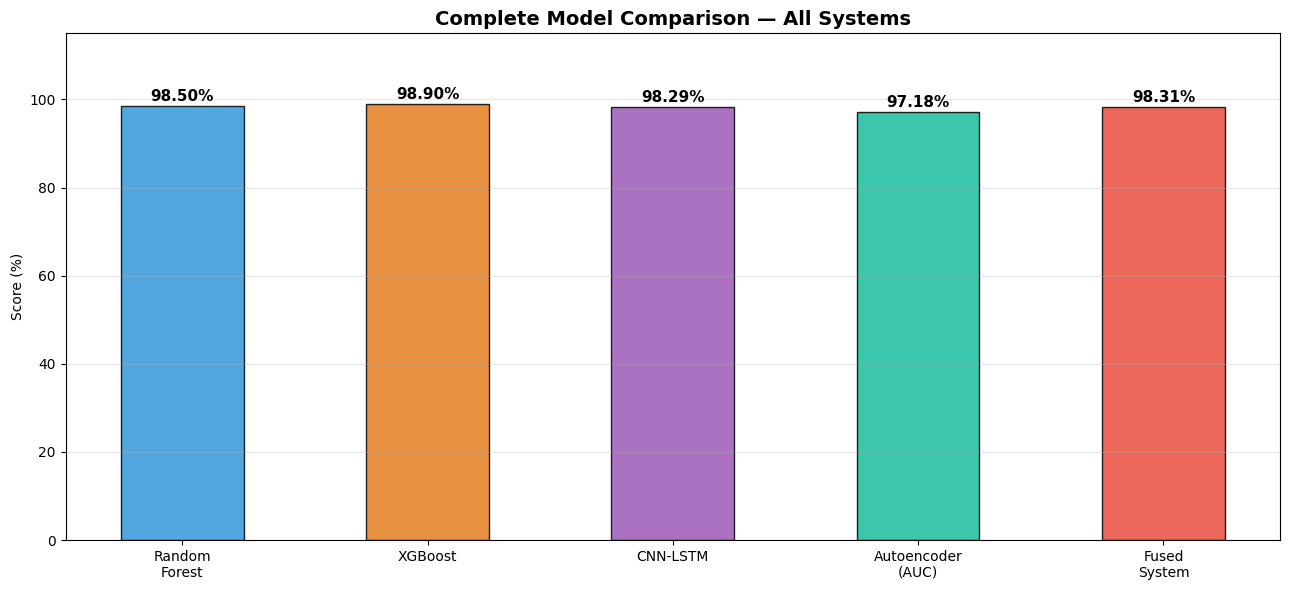

✅ Full comparison chart saved!


In [6]:
# CELL 6 — Full model comparison
# Add your Day 3 results here
rf_acc  = 0.985   # ← your RF accuracy
xgb_acc = 0.989   # ← your XGBoost accuracy

models = ['Random\nForest',
          'XGBoost',
          'CNN-LSTM',
          'Autoencoder\n(AUC)',
          'Fused\nSystem']
accs   = [rf_acc,
          xgb_acc,
          cnn_acc,
          ae_results['roc_auc'],
          fused_acc]
colors = ['#3498DB','#E67E22',
          '#9B59B6','#1ABC9C','#E74C3C']

plt.figure(figsize=(13, 6))
bars = plt.bar(models,
               [a*100 for a in accs],
               color=colors,
               edgecolor='black',
               alpha=0.85,
               width=0.5)

for bar, a in zip(bars, accs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{a*100:.2f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold')

plt.title('Complete Model Comparison — All Systems',
          fontsize=14, fontweight='bold')
plt.ylabel('Score (%)')
plt.ylim(0, 115)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/full_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Full comparison chart saved!")

In [7]:
# CELL 7 — SHAP for CNN-LSTM
print("Computing SHAP values...")
print("Takes 5-10 minutes...")

# Use small sample for SHAP speed
SHAP_SAMPLE = 200
background_size = 50

# Get sample
sample_idx  = np.random.choice(
    len(X_test), SHAP_SAMPLE, replace=False)
X_shap      = X_test_r[sample_idx]
background  = X_test_r[:background_size]

# GradientExplainer for deep models
explainer   = shap.GradientExplainer(
    cnn_model, background)
shap_values = explainer.shap_values(X_shap)

print(f"✅ SHAP values computed!")
print(f"   Shape: {np.array(shap_values).shape}")

Computing SHAP values...
Takes 5-10 minutes...
✅ SHAP values computed!
   Shape: (200, 20, 1, 27)


SHAP array shape: (200, 20, 1, 27)
shap_mean shape  : (27,)
top_features len : 20

✅ Top 10 important features:
   Local_13                           : 0.040219
   Bwd Segment Size Avg               : 0.032757
   Bwd RST Flags                      : 0.020621
   Src IP dec                         : 0.019828
   Subflow Bwd Bytes                  : 0.014848
   Local_9                            : 0.008950
   Average Packet Size                : 0.008582
   Bwd Packet Length Std              : 0.007455
   Bwd Packet Length Max              : 0.006990
   Local_14                           : 0.006031


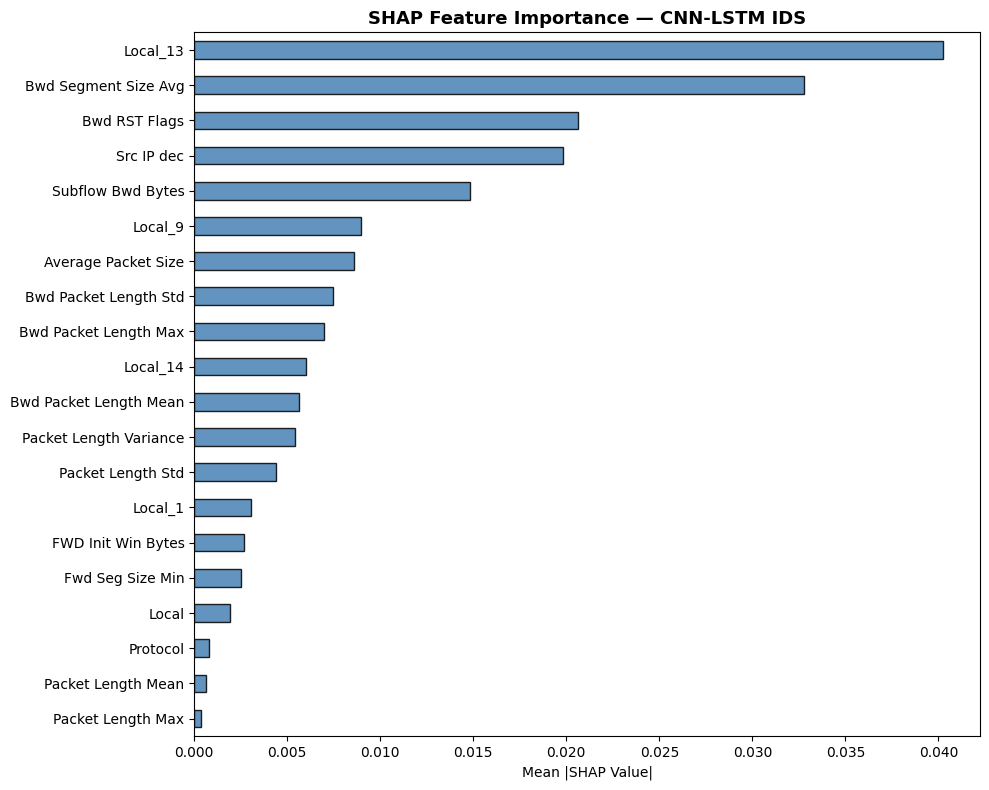

✅ SHAP importance plot saved!


In [8]:
# CELL 8 — SHAP summary plot (FIXED)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get SHAP array
shap_arr = np.array(shap_values)
print(f"SHAP array shape: {shap_arr.shape}")

# Fix — handle different SHAP output shapes
# shap_values can be (n_classes, n_samples, n_features, 1)
# or (n_samples, n_features, 1)
if len(shap_arr.shape) == 4:
    # Shape: (n_classes, n_samples, n_features, 1)
    # Average across classes and samples
    shap_mean = np.abs(shap_arr).mean(
        axis=(0, 1)).squeeze()
elif len(shap_arr.shape) == 3:
    # Shape: (n_samples, n_features, 1)
    shap_mean = np.abs(shap_arr).mean(
        axis=0).squeeze()
else:
    shap_mean = np.abs(shap_arr).mean(axis=0)

print(f"shap_mean shape  : {shap_mean.shape}")
print(f"top_features len : {len(top_features)}")

# Make sure lengths match
min_len = min(len(shap_mean), len(top_features))
shap_mean_trimmed    = shap_mean[:min_len]
top_features_trimmed = top_features[:min_len]

# Create series
feature_importance = pd.Series(
    shap_mean_trimmed,
    index=top_features_trimmed)
top_shap = feature_importance.nlargest(20)

print(f"\n✅ Top 10 important features:")
for feat, val in top_shap.nlargest(10).items():
    print(f"   {feat:35s}: {val:.6f}")

# Plot
plt.figure(figsize=(10, 8))
top_shap.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black',
    alpha=0.85)
plt.title('SHAP Feature Importance — CNN-LSTM IDS',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP importance plot saved!")

Analyzing false positives using SHAP...
Sample size           : 200
False positives found : 1
False positive rate   : 0.50%
SHAP array shape      : (200, 20, 1, 27)
fp_shap shape: (20,)

Top features causing FALSE POSITIVES:
   Packet Length Mean                 : 0.037706
   Local_13                           : 0.034648
   Bwd Packet Length Mean             : 0.023257
   Fwd Seg Size Min                   : 0.016729
   Local_1                            : 0.009195

💡 These features need retraining!


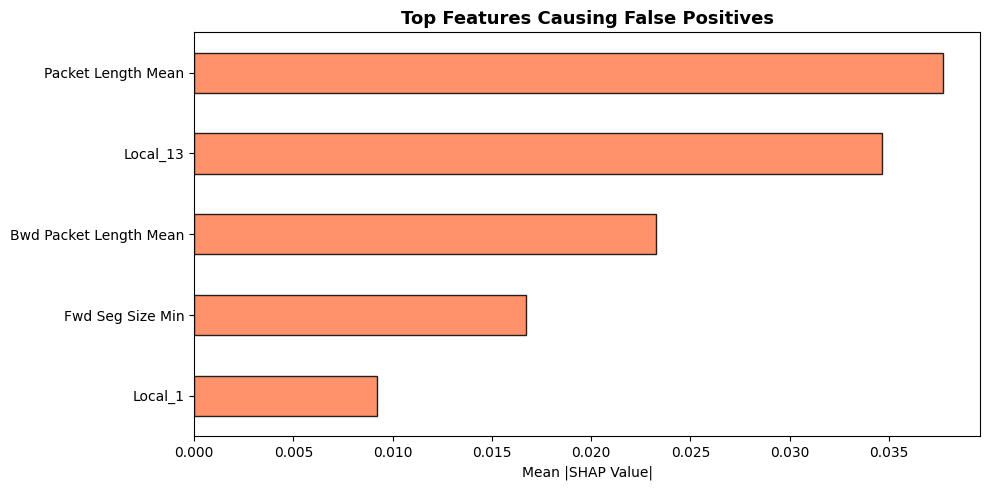

✅ FP analysis plot saved!


In [11]:
# CELL 9 — SHAP FP analysis (FIXED for shape 200,20,1,27)
print("Analyzing false positives using SHAP...")

y_sample      = y_test[sample_idx]
y_pred_sample = fused_preds[sample_idx]

# Find FP within sample only
fp_mask          = ((y_sample == benign_idx) &
                    (y_pred_sample != benign_idx))
fp_indices_local = np.where(fp_mask)[0]
fp_indices       = fp_indices_local  # save for Cell 10

print(f"Sample size           : {SHAP_SAMPLE}")
print(f"False positives found : {len(fp_indices_local)}")
print(f"False positive rate   : "
      f"{len(fp_indices_local)/SHAP_SAMPLE*100:.2f}%")

shap_arr = np.array(shap_values)
print(f"SHAP array shape      : {shap_arr.shape}")
# Shape is (200, 20, 1, 27)
# axis 0 = samples
# axis 1 = features
# axis 2 = timestep
# axis 3 = classes

if len(fp_indices_local) > 0:
    # Index on axis 0 (samples)
    fp_shap = np.abs(
        shap_arr[fp_indices_local, :, :, :]
    ).mean(axis=(0, 2, 3))
    # fp_shap shape is now (20,) = one value per feature

    print(f"fp_shap shape: {fp_shap.shape}")

    min_len = min(len(fp_shap), len(top_features))
    fp_importance = pd.Series(
        fp_shap[:min_len],
        index=top_features[:min_len])
    top_fp = fp_importance.nlargest(5)

    print(f"\nTop features causing FALSE POSITIVES:")
    for feat, val in top_fp.items():
        print(f"   {feat:35s}: {val:.6f}")
    print(f"\n💡 These features need retraining!")

    # Plot
    plt.figure(figsize=(10, 5))
    top_fp.sort_values().plot(
        kind='barh',
        color='coral',
        edgecolor='black',
        alpha=0.85)
    plt.title('Top Features Causing False Positives',
              fontsize=13, fontweight='bold')
    plt.xlabel('Mean |SHAP Value|')
    plt.tight_layout()
    plt.savefig('/kaggle/working/fp_features.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ FP analysis plot saved!")

else:
    print("✅ No false positives in sample!")
    top_fp        = pd.Series(dtype=float)
    fp_importance = pd.Series(dtype=float)

In [12]:
# CELL 10 — Save all results
print("Saving all results...")

top_fp_features   = (top_fp.index.tolist()
                     if len(top_fp) > 0 else [])
top_shap_features = (top_shap.nlargest(5).index.tolist()
                     if len(top_shap) > 0 else [])

final_results = {
    'cnn_lstm': {
        'accuracy': float(cnn_acc),
        'f1_score': float(cnn_f1)
    },
    'autoencoder': {
        'roc_auc'  : float(ae_results['roc_auc']),
        'threshold': float(threshold)
    },
    'fused_system': {
        'accuracy': float(fused_acc),
        'f1_score': float(fused_f1)
    },
    'shap_analysis': {
        'top_5_features'  : top_shap_features,
        'fp_count'        : int(len(fp_indices)),
        'fp_rate_percent' : float(
            len(fp_indices)/SHAP_SAMPLE*100),
        'top_fp_features' : top_fp_features
    },
    'decision_sources': dict(source_counts)
}

with open('/kaggle/working/day6_final_results.json',
          'w') as f:
    json.dump(final_results, f, indent=2)

print("\n✅ ALL DAY 6 FILES SAVED:")
print("=" * 50)
for fname in sorted(
        os.listdir('/kaggle/working/')):
    if not fname.startswith('.'):
        size = os.path.getsize(
            f'/kaggle/working/{fname}'
            ) // 1024 // 1024
        print(f"  └── {fname:<40s} {size:>4} MB")

print(f"\n{'='*50}")
print(f"🎉 DAY 6 COMPLETE!")
print(f"{'='*50}")
print(f"  CNN-LSTM Accuracy  : {cnn_acc*100:.2f}%")
print(f"  CNN-LSTM F1        : {cnn_f1:.4f}")
print(f"  AE ROC-AUC         : {ae_results['roc_auc']:.4f}")
print(f"  Fused Accuracy     : {fused_acc*100:.2f}%")
print(f"  Fused F1           : {fused_f1:.4f}")
print(f"  FP Count           : {len(fp_indices)}")
print(f"  FP Rate            : "
      f"{len(fp_indices)/SHAP_SAMPLE*100:.2f}%")
print(f"  Top SHAP Feature   : "
      f"{top_shap_features[0] if top_shap_features else 'N/A'}")
print(f"\n✅ Ready for Day 7 — Final Report!")

Saving all results...

✅ ALL DAY 6 FILES SAVED:
  └── day6_final_results.json                     0 MB
  └── fp_features.png                             0 MB
  └── full_comparison.png                         0 MB
  └── shap_importance.png                         0 MB

🎉 DAY 6 COMPLETE!
  CNN-LSTM Accuracy  : 98.29%
  CNN-LSTM F1        : 0.9864
  AE ROC-AUC         : 0.9718
  Fused Accuracy     : 98.31%
  Fused F1           : 0.9865
  FP Count           : 1
  FP Rate            : 0.50%
  Top SHAP Feature   : Local_13

✅ Ready for Day 7 — Final Report!
